In [11]:
import pandas as pd

# Ange sökväg till filen
file_path = "../Data/stresstest1/part8.csv"
#file_path = "../Data/stresstest2/raw/part8.csv"

# Läs in CSV
df = pd.read_csv(file_path)

# Lista kolumner
print("Kolumner:")
print(df.columns)

# Info om datatyper
print("\nData info:")
df.info()

# Snabb statistik
df.describe()

Kolumner:
Index(['PACKET_TS', 'SAMPLE_TS', 'PPG_RAW', 'PPG_FILT', 'GSR', 'HR', 'RMSSD',
       'SC_PH', 'SC_RR', 'CLASS', 'NUM_OF_CLASSIFICATIONS', 'EXP_PHASE'],
      dtype='str')

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 372600 entries, 0 to 372599
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   PACKET_TS               372600 non-null  int64  
 1   SAMPLE_TS               372600 non-null  int64  
 2   PPG_RAW                 372600 non-null  int64  
 3   PPG_FILT                372600 non-null  float64
 4   GSR                     372600 non-null  int64  
 5   HR                      372600 non-null  float64
 6   RMSSD                   372600 non-null  float64
 7   SC_PH                   372600 non-null  float64
 8   SC_RR                   372600 non-null  float64
 9   CLASS                   372600 non-null  int64  
 10  NUM_OF_CLASSIFICATIONS  372600 non-null  int64  
 11  

,PACKET_TS,SAMPLE_TS,PPG_RAW,PPG_FILT,GSR,HR,RMSSD,SC_PH,SC_RR,CLASS,NUM_OF_CLASSIFICATIONS,EXP_PHASE
count,3.726000e+05,3.726000e+05,372600.000000,372600.000000,372600.000000,372600.000000,372600.000000,372600.000000,372600.000000,372600.000000,372600.000000,372600.000000
mean,5.320922e+05,1.063656e+09,55345.381221,2.117092,1552.446490,67.099223,40.610909,1.175481,0.022598,0.155663,70.226516,6.879227
std,2.904212e+05,5.808427e+08,1593.219948,145.655337,225.983564,2.367836,7.412002,0.739881,0.035245,0.382703,38.622843,19.523631
min,2.907100e+04,5.713657e+07,51709.000000,-766.448669,993.000000,62.062061,20.658043,0.073874,0.000000,0.000000,3.000000,0.000000
25%,2.802550e+05,5.601980e+08,53954.000000,-118.986172,1451.000000,65.441795,35.235813,0.623138,0.000000,0.000000,37.000000,2.000000
50%,5.319150e+05,1.063270e+09,55220.000000,-30.813597,1599.000000,66.741959,40.329399,1.022239,0.000000,0.000000,70.000000,5.000000
75%,7.835730e+05,1.566333e+09,56885.000000,80.523693,1709.000000,68.535187,46.613102,1.664893,0.050000,0.000000,104.000000,9.000000
max,1.034696e+06,2.069392e+09,58723.000000,509.265472,2095.000000,72.971153,61.693443,4.150784,0.416667,2.000000,137.000000,255.000000


In [12]:
import numpy as np

fs = 200  # sampling frequency (Hz)

df['time_s'] = np.arange(len(df)) / fs
print("Total tid (sek):", df['time_s'].iloc[-1])
print("≈ minuter:", df['time_s'].iloc[-1] / 60)

Total tid (sek): 1862.995
≈ minuter: 31.049916666666665


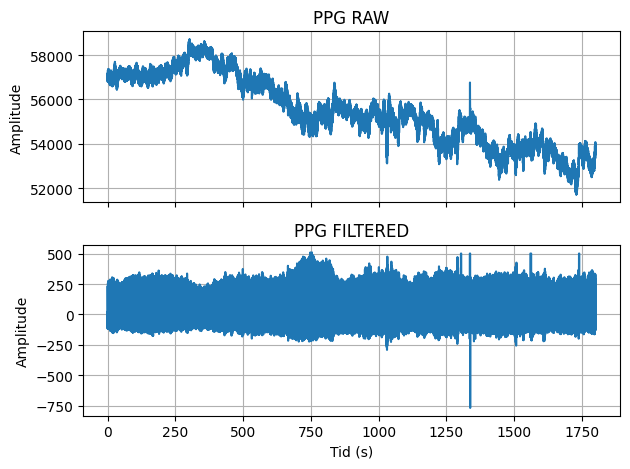

In [13]:
# 🔹 Cell 3.2 – PPG RAW och FILTERED i separata plots (inkl. tidsaxel)

import numpy as np
import matplotlib.pyplot as plt

# Säkerställ tidsaxel (200 Hz)
fs = 200
df['time_s'] = np.arange(len(df)) / fs

# Välj segment (t.ex. första 10 sek)
t_start = 0
t_end = 1800
df_segment = df[(df['time_s'] >= t_start) & (df['time_s'] <= t_end)].copy()

# Plot
fig, axs = plt.subplots(2, 1, sharex=True)

# PPG RAW
axs[0].plot(df_segment['time_s'], df_segment['PPG_RAW'])
axs[0].set_title("PPG RAW")
axs[0].set_ylabel("Amplitude")
axs[0].grid()

# PPG FILTERED
axs[1].plot(df_segment['time_s'], df_segment['PPG_FILT'])
axs[1].set_title("PPG FILTERED")
axs[1].set_ylabel("Amplitude")
axs[1].set_xlabel("Tid (s)")
axs[1].grid()

plt.tight_layout()
plt.show()

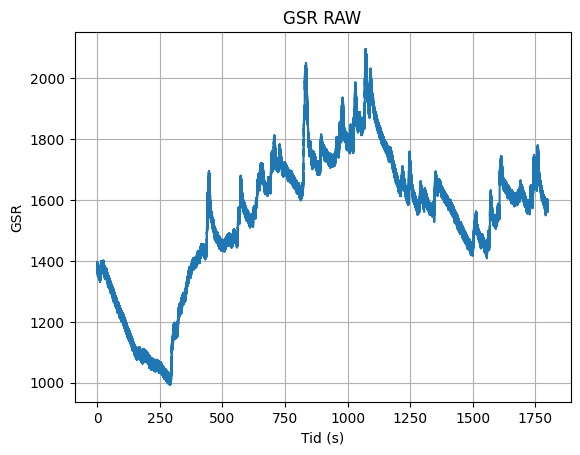

In [14]:
# 🔹 GSR plot (råsignal)

# Välj segment (samma som tidigare)
t_start = 0
t_end = 1800

df_segment = df[(df['time_s'] >= t_start) & (df['time_s'] <= t_end)].copy()

plt.figure()
plt.plot(df_segment['time_s'], df_segment['GSR'])
plt.title("GSR RAW")
plt.xlabel("Tid (s)")
plt.ylabel("GSR")
plt.grid()

plt.show()

In [152]:
# Välj features
df_features = df[['time_s', 'HR', 'RMSSD', 'SC_PH', 'SC_RR']].copy()

# 🔹 Konvertera till Timedelta (VIKTIGT)
df_features['time_s'] = pd.to_timedelta(df_features['time_s'], unit='s')

# Sätt som index
df_features.set_index('time_s', inplace=True)

# Resample till 2 sek
df_features = df_features.resample('2s').ffill()

# Tillbaka till sekunder
df_features.reset_index(inplace=True)
df_features['time_s'] = df_features['time_s'].dt.total_seconds()

df_features.head()

,time_s,HR,RMSSD,SC_PH,SC_RR
0,0.0,86.834106,57.115955,0.866482,0.0
1,2.0,87.657700,54.364479,0.915820,0.0
2,4.0,88.696159,55.126446,0.925851,0.0
3,6.0,89.177612,53.503914,0.922757,0.0
4,8.0,89.681885,51.525795,0.913072,0.0


In [153]:
# Välj class
df_class = df[['time_s', 'CLASS']].copy()

# Konvertera till Timedelta
df_class['time_s'] = pd.to_timedelta(df_class['time_s'], unit='s')

# Sätt index
df_class = df_class.set_index('time_s')

# Resample till 15 sek
df_class = df_class.resample('15s').ffill()

# Tillbaka till sekunder
df_class = df_class.reset_index()
df_class['time_s'] = df_class['time_s'].dt.total_seconds()


# Sortera (KRAV för merge_asof)
df_features = df_features.sort_values('time_s')
df_class = df_class.sort_values('time_s')

# Merge: matcha närmaste tidigare CLASS
df_merged = pd.merge_asof(
    df_features,
    df_class,
    on='time_s',
    direction='backward'
)

df_merged.head(10)

,time_s,HR,RMSSD,SC_PH,SC_RR,CLASS
0,0.0,86.834106,57.115955,0.866482,0.0,0
1,2.0,87.657700,54.364479,0.915820,0.0,0
2,4.0,88.696159,55.126446,0.925851,0.0,0
3,6.0,89.177612,53.503914,0.922757,0.0,0
4,8.0,89.681885,51.525795,0.913072,0.0,0
5,10.0,90.073868,46.396988,0.899614,0.0,0
6,12.0,89.695419,47.517509,0.880526,0.0,0
7,14.0,99.583084,36.849937,0.867948,0.0,0
8,16.0,91.586670,39.489857,0.814147,0.0,0
9,18.0,88.398209,41.959953,0.782615,0.0,0


In [154]:
df_merged[['time_s', 'HR', 'CLASS']].head(20)

,time_s,HR,CLASS
0,0.0,86.834106,0
1,2.0,87.657700,0
2,4.0,88.696159,0
3,6.0,89.177612,0
4,8.0,89.681885,0
5,10.0,90.073868,0
6,12.0,89.695419,0
7,14.0,99.583084,0
8,16.0,91.586670,0
9,18.0,88.398209,0


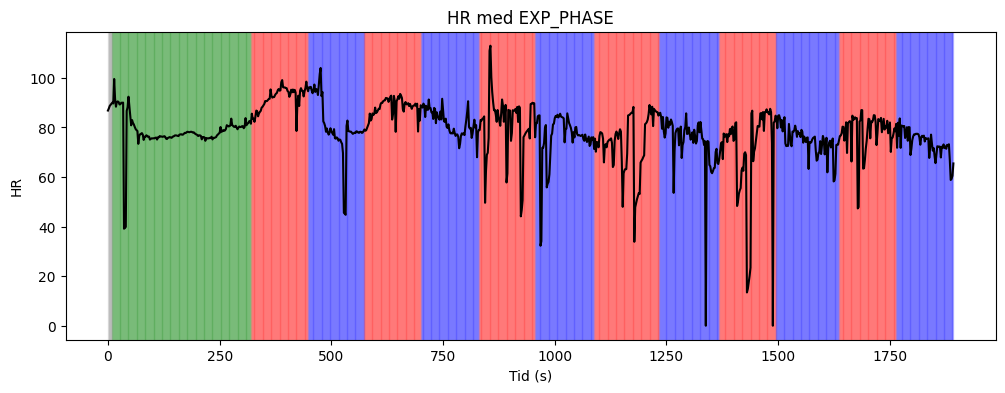

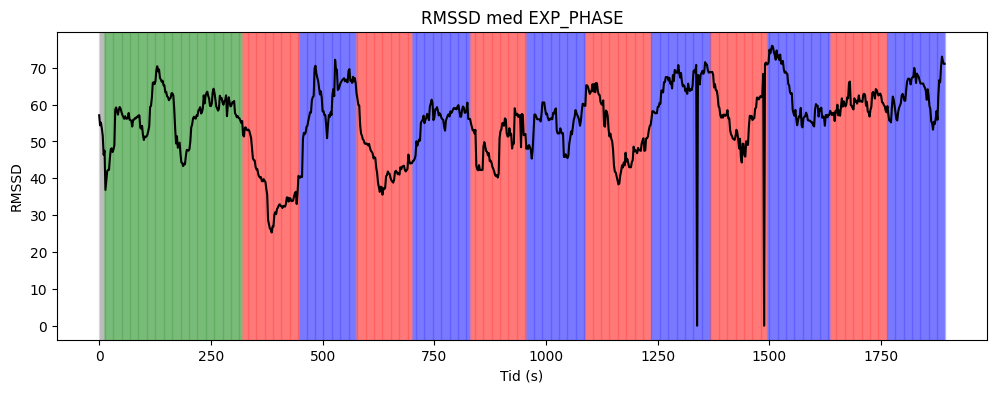

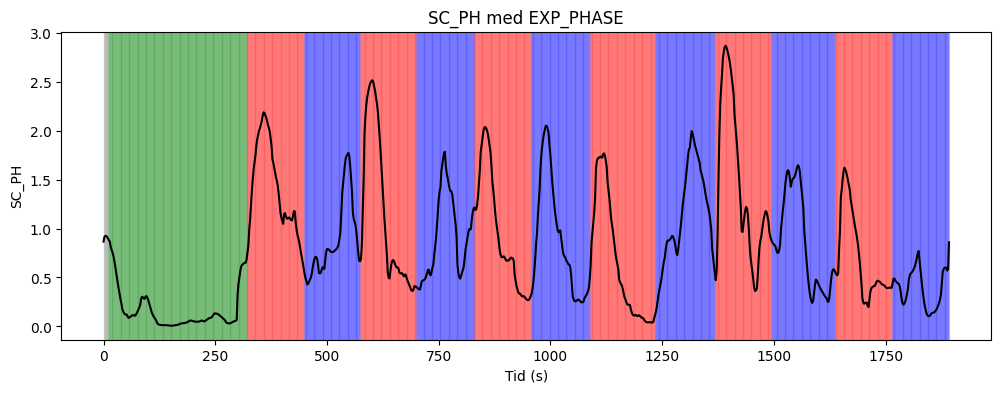

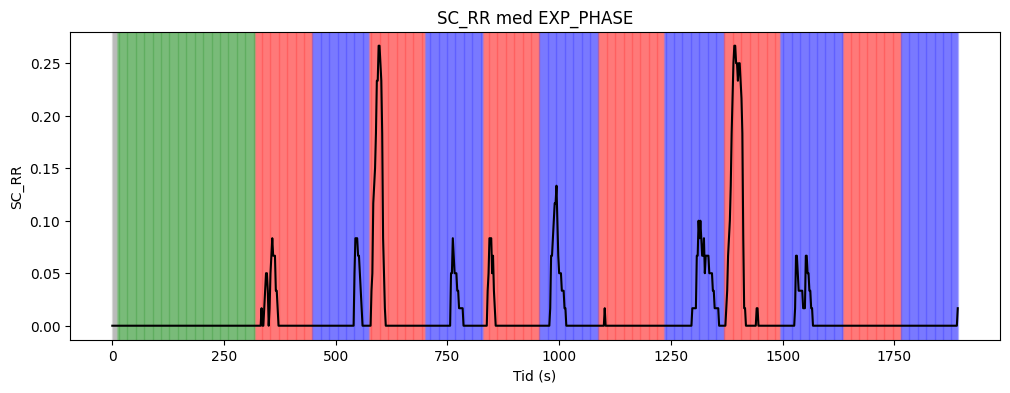

In [155]:
import matplotlib.pyplot as plt

# 🔹 Förbered EXP_PHASE (resampla till 2 sek)
df_phase = df[['time_s', 'EXP_PHASE']].copy()
df_phase['time_s'] = pd.to_timedelta(df_phase['time_s'], unit='s')
df_phase = df_phase.set_index('time_s').resample('2s').ffill()
df_phase = df_phase.reset_index()
df_phase['time_s'] = df_phase['time_s'].dt.total_seconds()

# 🔹 Merge med features
df_plot = pd.merge_asof(
    df_features.sort_values('time_s'),
    df_phase.sort_values('time_s'),
    on='time_s'
)

# 🔹 Egen färglogik
phase_color_map = {}

for phase in df_plot['EXP_PHASE'].unique():
    if phase == 0:
        phase_color_map[phase] = 'green'
    elif phase in [2,4,6,8,10,12]:
        phase_color_map[phase] = 'blue'
    elif phase in [1,3,5,7,9,11]:
        phase_color_map[phase] = 'red'
    else:
        phase_color_map[phase] = 'gray'  # t.ex. 255

features = ['HR', 'RMSSD', 'SC_PH', 'SC_RR']

# 🔹 Loop plots
for feature in features:
    fig, ax = plt.subplots(figsize=(12, 4))

    # Bakgrund (phase)
    for i in range(len(df_plot)-1):
        t0 = df_plot['time_s'].iloc[i]
        t1 = df_plot['time_s'].iloc[i+1]
        phase = df_plot['EXP_PHASE'].iloc[i]
        ax.axvspan(t0, t1, color=phase_color_map[phase], alpha=0.2)

    # Signal
    ax.plot(df_plot['time_s'], df_plot[feature], color='black')

    ax.set_title(f"{feature} med EXP_PHASE")
    ax.set_xlabel("Tid (s)")
    ax.set_ylabel(feature)

    plt.show()

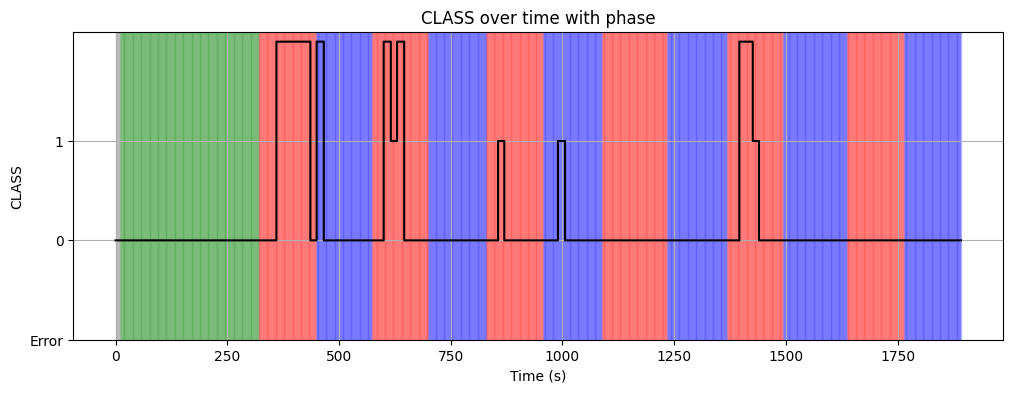

In [156]:
import matplotlib.pyplot as plt

# 🔹 Förbered EXP_PHASE (2 sek)
df_phase = df[['time_s', 'EXP_PHASE']].copy()
df_phase['time_s'] = pd.to_timedelta(df_phase['time_s'], unit='s')
df_phase = df_phase.set_index('time_s').resample('2s').ffill()
df_phase = df_phase.reset_index()
df_phase['time_s'] = df_phase['time_s'].dt.total_seconds()

# 🔹 Merge med CLASS
df_class_plot = pd.merge_asof(
    df_merged[['time_s', 'CLASS']].sort_values('time_s'),
    df_phase.sort_values('time_s'),
    on='time_s'
)

# 🔹 Skapa plot-version av CLASS (255 → -1)
df_class_plot['CLASS_plot'] = df_class_plot['CLASS'].replace(255, -1)

# 🔹 Färglogik för faser
phase_color_map = {}

for phase in df_class_plot['EXP_PHASE'].unique():
    if phase == 0:
        phase_color_map[phase] = 'green'
    elif phase in [2,4,6,8,10,12]:
        phase_color_map[phase] = 'blue'
    elif phase in [1,3,5,7,9,11]:
        phase_color_map[phase] = 'red'
    else:
        phase_color_map[phase] = 'gray'  # t.ex. 255

# 🔹 Plot
fig, ax = plt.subplots(figsize=(12, 4))

# Bakgrund (phase)
for i in range(len(df_class_plot)-1):
    t0 = df_class_plot['time_s'].iloc[i]
    t1 = df_class_plot['time_s'].iloc[i+1]
    phase = df_class_plot['EXP_PHASE'].iloc[i]
    
    ax.axvspan(t0, t1, color=phase_color_map[phase], alpha=0.2)

# CLASS som stegfunktion
ax.step(df_class_plot['time_s'], df_class_plot['CLASS_plot'], where='post', color='black')

# 🔹 Y-axel tydlig
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Error', '0', '1'])

ax.set_title("CLASS over time with phase")
ax.set_xlabel("Time (s)")
ax.set_ylabel("CLASS")

plt.grid()
plt.show()

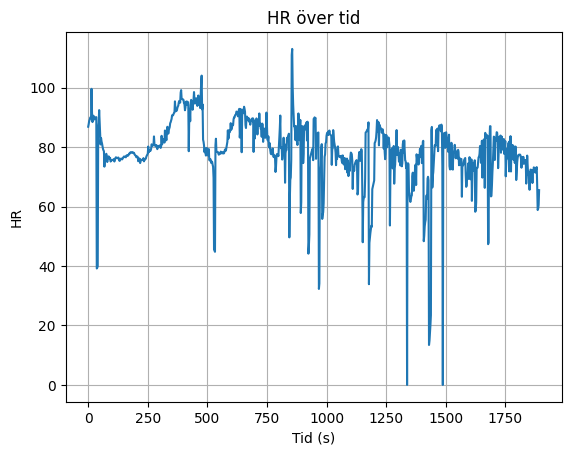

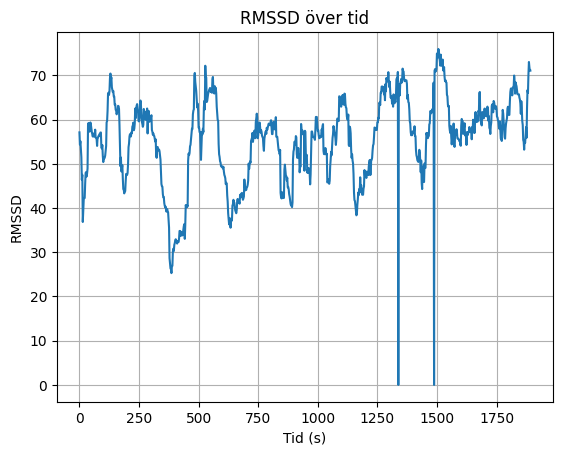

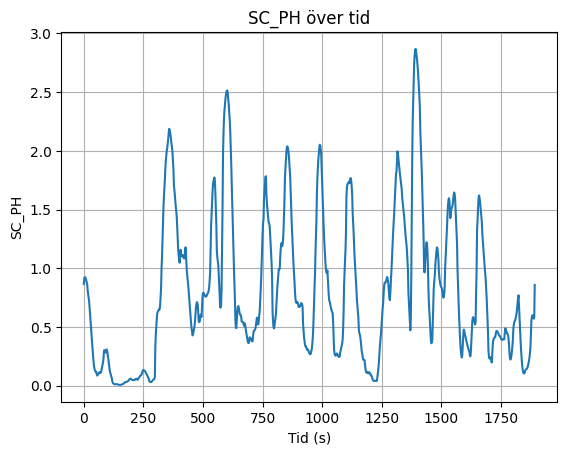

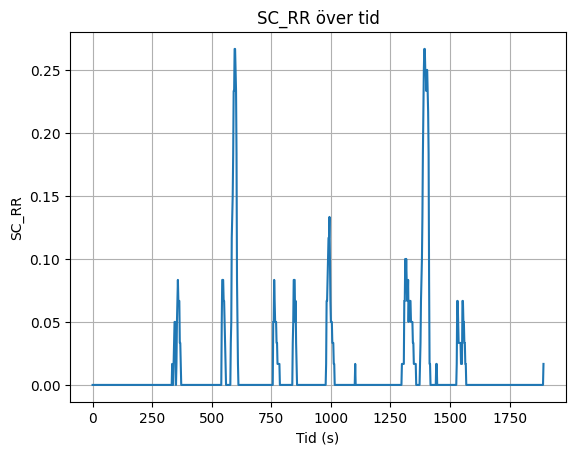

In [157]:
features = ['HR', 'RMSSD', 'SC_PH', 'SC_RR']

for feature in features:
    plt.figure()
    plt.plot(df_features['time_s'], df_features[feature])
    plt.title(f"{feature} över tid")
    plt.xlabel("Tid (s)")
    plt.ylabel(feature)
    plt.grid()
    plt.show()

In [158]:
# 🔹 CLASS sammanfattning

import matplotlib.pyplot as plt

# --- 1. Antal per CLASS ---
class_counts = df_merged['CLASS'].value_counts().sort_index()

print("Antal per CLASS:")
print(class_counts)

# --- 2. Procent ---
print("\nProcent (%):")
print((class_counts / len(df_merged)) * 100)

# --- 3. Tid per CLASS ---
time_per_sample = 2  # sek (eftersom features är var 2 sek)

class_duration = class_counts * time_per_sample

print("\nTid per CLASS (sek):")
print(class_duration)

print("\nTid per CLASS (min):")
print(class_duration / 60)

# --- 4. Antal segment ---
df_merged['class_change'] = df_merged['CLASS'].diff().fillna(0) != 0
num_segments = df_merged['class_change'].sum()

print("\nAntal CLASS-segment:", int(num_segments))



Antal per CLASS:
CLASS
0    841
1     29
2     77
Name: count, dtype: int64

Procent (%):
CLASS
0    88.806758
1     3.062302
2     8.130940
Name: count, dtype: float64

Tid per CLASS (sek):
CLASS
0    1682
1      58
2     154
Name: count, dtype: int64

Tid per CLASS (min):
CLASS
0    28.033333
1     0.966667
2     2.566667
Name: count, dtype: float64

Antal CLASS-segment: 15


In [159]:
# 🔹 Features per CLASS – sammanfattning

feature_cols = ['HR', 'RMSSD', 'SC_PH', 'SC_RR']

# Gruppanalys
df_stats = df_merged.groupby('CLASS')[feature_cols].agg(['mean', 'std', 'min', 'max', 'count'])


# 🔹 Platt tabell
df_mean = df_merged.groupby('CLASS')[feature_cols].mean()
df_std = df_merged.groupby('CLASS')[feature_cols].std()

print("Mean per CLASS:")
print(df_mean)

print("\nStd per CLASS:")
print(df_std)

Mean per CLASS:
              HR      RMSSD     SC_PH     SC_RR
CLASS                                          
0      78.008773  57.057388  0.728947  0.009532
1      74.569347  49.291495  1.619397  0.024138
2      87.447550  40.843389  1.504721  0.040043

Std per CLASS:
              HR     RMSSD     SC_PH     SC_RR
CLASS                                         
0       9.636054  8.546690  0.583249  0.032172
1      27.860744  7.201953  0.375333  0.042395
2      12.293593  9.547349  0.710234  0.081077


In [160]:
feature_cols = ['HR', 'RMSSD', 'SC_PH', 'SC_RR']

# Gruppanalys per fas
df_phase_stats = df_plot.groupby('EXP_PHASE')[feature_cols].agg(['mean', 'std', 'min', 'max', 'count'])

print("Statistik per EXP_PHASE:")
print(df_phase_stats)

Statistik per EXP_PHASE:
                  HR                                              RMSSD  \
                mean        std        min         max count       mean   
EXP_PHASE                                                                 
0          78.428274   7.102746  39.160385   99.583084   155  56.761926   
1          91.758502   4.565916  78.599007   99.134964    64  38.302602   
2          81.115914  11.722994  44.762646  104.025703    63  60.899870   
3          87.724419   4.111204  78.254097   93.548080    63  44.867723   
4          82.091010   5.117581  67.998978   91.592606    65  55.980470   
5          81.485709  12.680088  44.144203  113.000465    63  49.696482   
6          76.301414  10.040004  32.278179   85.694458    66  54.097899   
7          73.661326  11.644885  33.873577   89.067230    73  51.932965   
8          74.575606  11.498044   0.000000   85.935524    67  64.487275   
9          69.696356  20.374078   0.000000   87.542114    63  56.203607   


In [161]:
df_phase_mean = df_plot.groupby('EXP_PHASE')[feature_cols].mean()

print("Mean per EXP_PHASE:")
print(df_phase_mean)

Mean per EXP_PHASE:
                  HR      RMSSD     SC_PH     SC_RR
EXP_PHASE                                          
0          78.428274  56.761926  0.170698  0.000000
1          91.758502  38.302602  1.412941  0.010938
2          81.115914  60.899870  0.886572  0.008466
3          87.724419  44.867723  1.159223  0.039418
4          82.091010  55.980470  0.911999  0.008462
5          81.485709  49.696482  0.973175  0.007937
6          76.301414  54.097899  0.885746  0.017424
7          73.661326  51.932965  0.656831  0.000228
8          74.575606  64.487275  1.122048  0.021891
9          69.696356  56.203607  1.447876  0.057672
10         74.842767  62.525308  0.862250  0.010563
11         78.269315  60.431676  0.706541  0.000000
12         73.849868  62.701875  0.395775  0.000256
255        88.409492  54.327318  0.908796  0.000000


In [162]:
feature_cols = ['HR', 'RMSSD', 'SC_PH', 'SC_RR']

# Sammanfattning
df_summary = df_merged[feature_cols].agg(['mean', 'std', 'min', 'max'])

print("Sammanfattning av features (hela datasetet):")
print(df_summary)

Sammanfattning av features (hela datasetet):
              HR      RMSSD     SC_PH     SC_RR
mean   78.670909  55.501222  0.819293  0.012460
std    11.168755   9.723280  0.641777  0.039675
min     0.000000   0.000000  0.007106  0.000000
max   113.000465  75.988701  2.868521  0.266667
